=== DEBUG: DYNAMIC PCA IS BEING USED ===
vol_loadings shape: (7, 7)
First element of loadings: 0.4441

True model log(h_sim) correlations (should now match original):
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.59        0.58   -0.10   0.54   0.60          0.15
guitars         0.59     1.00        0.69   -0.24   0.67   0.55         -0.09
slingshots      0.58     0.69        1.00   -0.06   0.65   0.47          0.29
stocks         -0.10    -0.24       -0.06    1.00  -0.22  -0.13          0.20
sugar           0.54     0.67        0.65   -0.22   1.00   0.32          0.10
water           0.60     0.55        0.47   -0.13   0.32   1.00          0.16
tranquillity    0.15    -0.09        0.29    0.20   0.10   0.16          1.00
VALIDATION

Correlation matrix comparison:
Original:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.326      -0.291  -0.045 -0.081  0.623        -0.148


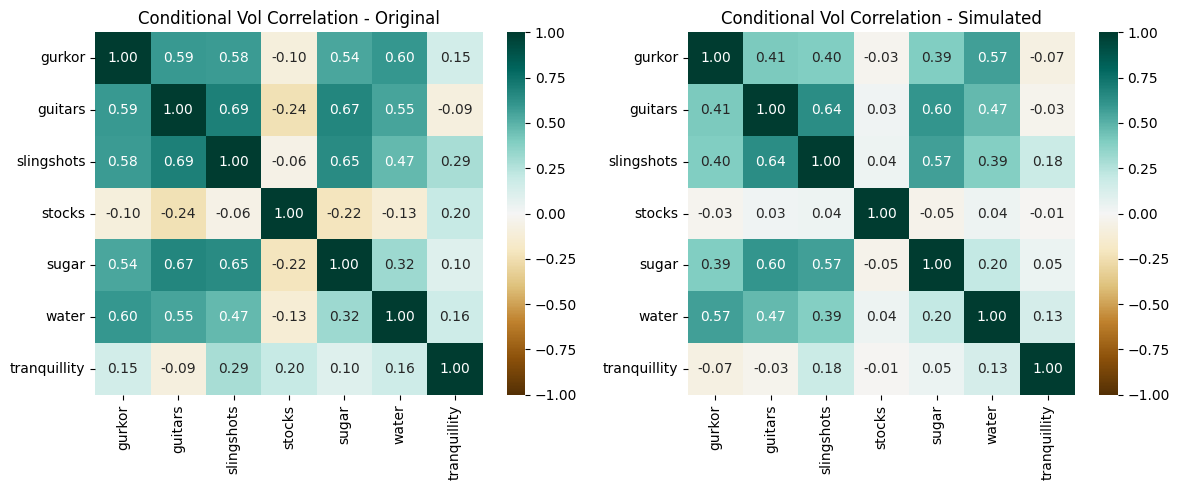


MAE of vol correlations: 0.118


In [5]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t as student_t
from numpy.linalg import eigh

THEME = 'BrBG'

# =============================================================================
# Load data
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

df_og_returns = (df_original / df_original.shift(1) - 1).dropna() 
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
original_stds = df_og_returns.std()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# =============================================================================
# Parameters (same as before)
# =============================================================================
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557],
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590],
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809],
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002],
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988],
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336],
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]
])

Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700],
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445],
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037],
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329],
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718],
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123],
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]
])

# Kurtosis parameters (same as before)
nu_obs = {
    'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
    'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41
}
nu_target = {
    'gurkor': 5.66, 'guitars': 5.04, 'slingshots': 5.28,
    'stocks': 132.55, 'sugar': 4.45, 'water': 7.65, 'tranquillity': 6.31
}
alpha_blend = {
    'gurkor': 0.85, 'guitars': 0.727, 'slingshots': 1.034,
    'stocks': 0.8, 'sugar': 0.973, 'water': 0.93, 'tranquillity': 0.77,
}
nu_blended = {col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col]) for col in var_names}
nu_blended = nu_target # Note: this is just for now as i am unsure of the alphas.
t_scales = {col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2)) for col in var_names}



# =============================================================================
# VOLATILITY FACTOR MODEL — COMPUTED FROM DATA (this is the ONLY version)
# =============================================================================
# 1. Fit univariate GARCH(1,1) on original data
cond_var_og = pd.DataFrame(index=df_og_returns.index, columns=var_names)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2

log_h_og = np.log(cond_var_og)
log_h_means = log_h_og.mean().values
log_h_stds  = log_h_og.std().values

log_h_std = (log_h_og - log_h_means) / log_h_stds

n_pc = 7
pca = PCA(n_components=n_pc)
pca_factors = pca.fit_transform(log_h_std)
vol_loadings = pca.components_.T

# DEBUG — this proves we are using the dynamic version
print("=== DEBUG: DYNAMIC PCA IS BEING USED ===")
print("vol_loadings shape:", vol_loadings.shape)
print("First element of loadings:", round(vol_loadings[0,0], 4))

vol_factor_params = {}
for k in range(n_pc):
    factor = pca_factors[:, k]
    X = np.column_stack((np.ones(len(factor)-1), factor[:-1]))
    beta = np.linalg.lstsq(X, factor[1:], rcond=None)[0]
    c, phi = beta
    resid = factor[1:] - X @ beta
    resid_std = resid.std(ddof=1)
    target_std = factor.std(ddof=1)
    vol_factor_params[f'PC{k+1}'] = {
        'phi': float(phi),
        'c': float(c),
        'resid_std': float(resid_std),
        'target_std': float(target_std)
    }


og_corr = df_og_returns.corr().values
eigenvalues, eigenvectors = eigh(og_corr)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)


# =============================================================================
# Simulation (uses the dynamic parameters above)
# =============================================================================
np.random.seed(42)
T = 4000
burn = 500
T_total = T + burn

F_sim = np.zeros((T_total, 7))
for t in range(2, T_total):
    F_sim[t] = Phi1 @ F_sim[t-1] + Phi2 @ F_sim[t-2] + np.random.randn(7)

vol_factors = np.zeros((T_total, n_pc))
for k in range(n_pc):
    p = vol_factor_params[f'PC{k+1}']
    phi, c, sigma = p['phi'], p['c'], p['resid_std']
    # Initialize at unconditional mean
    vol_factors[0, k] = c / (1 - phi) if abs(phi) < 1 else 0
    for t in range(1, T_total):
        vol_factors[t, k] = c + phi * vol_factors[t-1, k] + sigma * np.random.randn()

# Standardize to exactly match target variances while preserving correlation structure
# Target covariance should be diagonal with target_std^2 on diagonal
target_cov = np.diag([vol_factor_params[f'PC{k+1}']['target_std']**2 for k in range(n_pc)])
current_cov = np.cov(vol_factors, rowvar=False)
# Matrix square root correction to force exact covariance
current_cov_sqrt = np.linalg.cholesky(current_cov + np.eye(n_pc)*1e-10)
target_cov_sqrt = np.linalg.cholesky(target_cov)
transform = target_cov_sqrt @ np.linalg.inv(current_cov_sqrt)
vol_factors = vol_factors @ transform.T

log_h_std_sim = vol_factors @ vol_loadings.T
log_h_sim = log_h_std_sim * log_h_stds + log_h_means
h_sim = np.exp(log_h_sim)

print("\nTrue model log(h_sim) correlations (should now match original):")
true_log_h_corr = pd.DataFrame(np.log(h_sim), columns=var_names).corr().round(2)
print(true_log_h_corr)

F_sim = F_sim[burn:]
h_sim = h_sim[burn:]

Y_sim = F_sim @ Lambda_corrected.T
Y_sim_std = Y_sim / Y_sim.std(axis=0)
Z = Y_sim_std

Y_final = np.zeros_like(Y_sim)
for t in range(len(Y_sim)):
    uniform = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])
    Y_final[t] = correlated_t * np.sqrt(h_sim[t])

df_returns_final = pd.DataFrame(Y_final, columns=var_names)
df_returns_final = df_returns_final.multiply(original_stds / df_returns_final.std(), axis=1)
# =============================================================================
# Validation
# =============================================================================
print("="*60)
print("VALIDATION")
print("="*60)

print("\nCorrelation matrix comparison:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\nGARCH persistence on simulated series:")
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean = 'Zero').fit(disp='off')
    p_sim = res.params['alpha[1]'] + res.params['beta[1]']
    print(f"  {col}: {p_sim:.4f}")

# =============================================================================
# Conditional volatility correlation comparison
# =============================================================================
print("\n" + "="*60)
print("CONDITIONAL VOLATILITY CORRELATIONS")
print("="*60)

# Fit GARCH to simulated returns, extract conditional variances
cond_var_sim = pd.DataFrame(index=range(len(df_returns_final)))
for col in var_names:
    model = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_sim[col] = res.conditional_volatility ** 2

# Fit GARCH to original returns
cond_var_og = pd.DataFrame(index=df_og_returns.index)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2

print("\nOriginal conditional vol correlations:")
print(np.log(cond_var_og).corr().round(2))
print("\nSimulated conditional vol correlations:")
print(np.log(cond_var_sim).corr().round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(np.log(cond_var_og).corr(), annot=True, fmt='.2f', cmap=THEME, 
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation - Original')
sns.heatmap(np.log(cond_var_sim).corr(), annot=True, fmt='.2f', cmap=THEME, 
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation - Simulated')
plt.tight_layout()
plt.show()

# Error metrics
og_vol_corr = np.log(cond_var_og).corr().values
sim_vol_corr = np.log(cond_var_sim).corr().values
mask = ~np.eye(7, dtype=bool)
mae = np.mean(np.abs(og_vol_corr[mask] - sim_vol_corr[mask]))
print(f"\nMAE of vol correlations: {mae:.3f}")

=== DEBUG: DYNAMIC PCA IS BEING USED ===
vol_loadings shape: (7, 7)
First element of loadings: 0.4441

True model log(h_sim) correlations (should now match original):
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00     0.59        0.58   -0.10   0.54   0.60          0.15
guitars         0.59     1.00        0.69   -0.24   0.67   0.55         -0.09
slingshots      0.58     0.69        1.00   -0.06   0.65   0.47          0.29
stocks         -0.10    -0.24       -0.06    1.00  -0.22  -0.13          0.20
sugar           0.54     0.67        0.65   -0.22   1.00   0.32          0.10
water           0.60     0.55        0.47   -0.13   0.32   1.00          0.16
tranquillity    0.15    -0.09        0.29    0.20   0.10   0.16          1.00
VALIDATION

Correlation matrix comparison:
Original:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.326      -0.291  -0.045 -0.081  0.623        -0.148


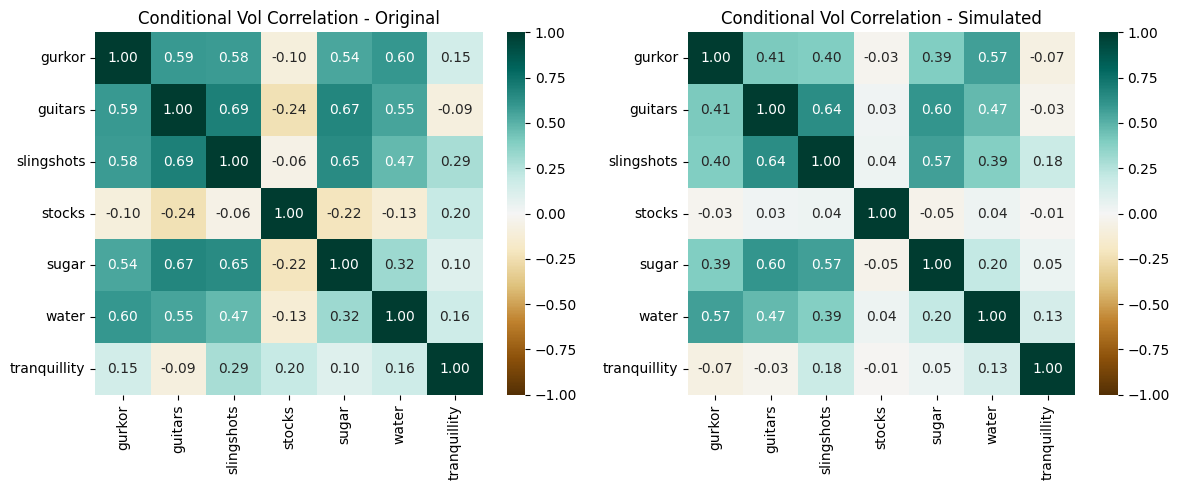


MAE of vol correlations: 0.118


In [6]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, t as student_t
from numpy.linalg import eigh

THEME = 'BrBG'

# =============================================================================
# Load data
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

df_og_returns = (df_original / df_original.shift(1) - 1).dropna() 
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
original_stds = df_og_returns.std()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# =============================================================================
# Parameters (same as before)
# =============================================================================
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557],
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590],
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809],
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002],
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988],
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336],
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]
])

Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700],
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445],
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037],
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329],
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718],
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123],
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]
])

# Kurtosis parameters (same as before)
nu_obs = {
    'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
    'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41
}
nu_target = {
    'gurkor': 5.66, 'guitars': 5.04, 'slingshots': 5.28,
    'stocks': 132.55, 'sugar': 4.45, 'water': 7.65, 'tranquillity': 6.31
}
alpha_blend = {
    'gurkor': 0.85, 'guitars': 0.727, 'slingshots': 1.034,
    'stocks': 0.8, 'sugar': 0.973, 'water': 0.93, 'tranquillity': 0.77,
}
nu_blended = {col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col]) for col in var_names}
nu_blended = nu_target # Note: this is just for now as i am unsure of the alphas.
t_scales = {col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2)) for col in var_names}



# =============================================================================
# VOLATILITY FACTOR MODEL — COMPUTED FROM DATA (this is the ONLY version)
# =============================================================================
# 1. Fit univariate GARCH(1,1) on original data
cond_var_og = pd.DataFrame(index=df_og_returns.index, columns=var_names)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2

log_h_og = np.log(cond_var_og)
log_h_means = log_h_og.mean().values
log_h_stds  = log_h_og.std().values

log_h_std = (log_h_og - log_h_means) / log_h_stds

n_pc = 7
pca = PCA(n_components=n_pc)
pca_factors = pca.fit_transform(log_h_std)
vol_loadings = pca.components_.T

# DEBUG — this proves we are using the dynamic version
print("=== DEBUG: DYNAMIC PCA IS BEING USED ===")
print("vol_loadings shape:", vol_loadings.shape)
print("First element of loadings:", round(vol_loadings[0,0], 4))

vol_factor_params = {}
for k in range(n_pc):
    factor = pca_factors[:, k]
    X = np.column_stack((np.ones(len(factor)-1), factor[:-1]))
    beta = np.linalg.lstsq(X, factor[1:], rcond=None)[0]
    c, phi = beta
    resid = factor[1:] - X @ beta
    resid_std = resid.std(ddof=1)
    target_std = factor.std(ddof=1)
    vol_factor_params[f'PC{k+1}'] = {
        'phi': float(phi),
        'c': float(c),
        'resid_std': float(resid_std),
        'target_std': float(target_std)
    }


og_corr = df_og_returns.corr().values
eigenvalues, eigenvectors = eigh(og_corr)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)


# =============================================================================
# Simulation (uses the dynamic parameters above)
# =============================================================================
np.random.seed(42)
T = 4000
burn = 500
T_total = T + burn

F_sim = np.zeros((T_total, 7))
for t in range(2, T_total):
    F_sim[t] = Phi1 @ F_sim[t-1] + Phi2 @ F_sim[t-2] + np.random.randn(7)

vol_factors = np.zeros((T_total, n_pc))
for k in range(n_pc):
    p = vol_factor_params[f'PC{k+1}']
    phi, c, sigma = p['phi'], p['c'], p['resid_std']
    # Initialize at unconditional mean
    vol_factors[0, k] = c / (1 - phi) if abs(phi) < 1 else 0
    for t in range(1, T_total):
        vol_factors[t, k] = c + phi * vol_factors[t-1, k] + sigma * np.random.randn()

# Standardize to exactly match target variances while preserving correlation structure
# Target covariance should be diagonal with target_std^2 on diagonal
target_cov = np.diag([vol_factor_params[f'PC{k+1}']['target_std']**2 for k in range(n_pc)])
current_cov = np.cov(vol_factors, rowvar=False)
# Matrix square root correction to force exact covariance
current_cov_sqrt = np.linalg.cholesky(current_cov + np.eye(n_pc)*1e-10)
target_cov_sqrt = np.linalg.cholesky(target_cov)
transform = target_cov_sqrt @ np.linalg.inv(current_cov_sqrt)
vol_factors = vol_factors @ transform.T

log_h_std_sim = vol_factors @ vol_loadings.T
log_h_sim = log_h_std_sim * log_h_stds + log_h_means
h_sim = np.exp(log_h_sim)

print("\nTrue model log(h_sim) correlations (should now match original):")
true_log_h_corr = pd.DataFrame(np.log(h_sim), columns=var_names).corr().round(2)
print(true_log_h_corr)

F_sim = F_sim[burn:]
h_sim = h_sim[burn:]

Y_sim = F_sim @ Lambda_corrected.T
Y_sim_std = Y_sim / Y_sim.std(axis=0)
Z = Y_sim_std

Y_final = np.zeros_like(Y_sim)
for t in range(len(Y_sim)):
    uniform = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])
    Y_final[t] = correlated_t * np.sqrt(h_sim[t])

df_returns_final = pd.DataFrame(Y_final, columns=var_names)
df_returns_final = df_returns_final.multiply(original_stds / df_returns_final.std(), axis=1)
# =============================================================================
# Validation
# =============================================================================
print("="*60)
print("VALIDATION")
print("="*60)

print("\nCorrelation matrix comparison:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

print("\nKurtosis comparison:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\nGARCH persistence on simulated series:")
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean = 'Zero').fit(disp='off')
    p_sim = res.params['alpha[1]'] + res.params['beta[1]']
    print(f"  {col}: {p_sim:.4f}")

# =============================================================================
# Conditional volatility correlation comparison
# =============================================================================
print("\n" + "="*60)
print("CONDITIONAL VOLATILITY CORRELATIONS")
print("="*60)

# Fit GARCH to simulated returns, extract conditional variances
cond_var_sim = pd.DataFrame(index=range(len(df_returns_final)))
for col in var_names:
    model = arch_model(df_returns_final[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_sim[col] = res.conditional_volatility ** 2

# Fit GARCH to original returns
cond_var_og = pd.DataFrame(index=df_og_returns.index)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var_og[col] = res.conditional_volatility ** 2

print("\nOriginal conditional vol correlations:")
print(np.log(cond_var_og).corr().round(2))
print("\nSimulated conditional vol correlations:")
print(np.log(cond_var_sim).corr().round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(np.log(cond_var_og).corr(), annot=True, fmt='.2f', cmap=THEME, 
            center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation - Original')
sns.heatmap(np.log(cond_var_sim).corr(), annot=True, fmt='.2f', cmap=THEME, 
            center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation - Simulated')
plt.tight_layout()
plt.show()

# Error metrics
og_vol_corr = np.log(cond_var_og).corr().values
sim_vol_corr = np.log(cond_var_sim).corr().values
mask = ~np.eye(7, dtype=bool)
mae = np.mean(np.abs(og_vol_corr[mask] - sim_vol_corr[mask]))
print(f"\nMAE of vol correlations: {mae:.3f}")

RECONSTRUCTION QUALITY BY NUMBER OF FACTORS

1 factor(s): 47.8% variance explained
  Correlation recovery: 0.732
  MAE: 0.675, Max error: 1.201

2 factor(s): 66.3% variance explained
  Correlation recovery: 0.944
  MAE: 0.280, Max error: 0.652

3 factor(s): 77.1% variance explained
  Correlation recovery: 0.961
  MAE: 0.208, Max error: 0.645

4 factor(s): 87.5% variance explained
  Correlation recovery: 0.989
  MAE: 0.100, Max error: 0.296

5 factor(s): 93.2% variance explained
  Correlation recovery: 0.992
  MAE: 0.057, Max error: 0.195


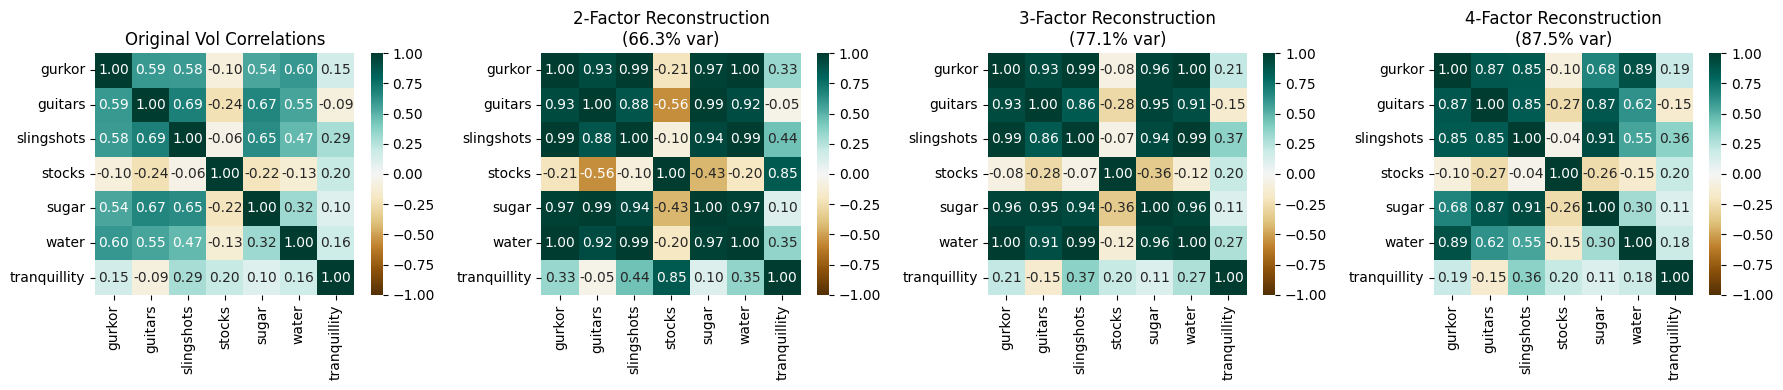


DYNAMICS OF EACH VOLATILITY FACTOR


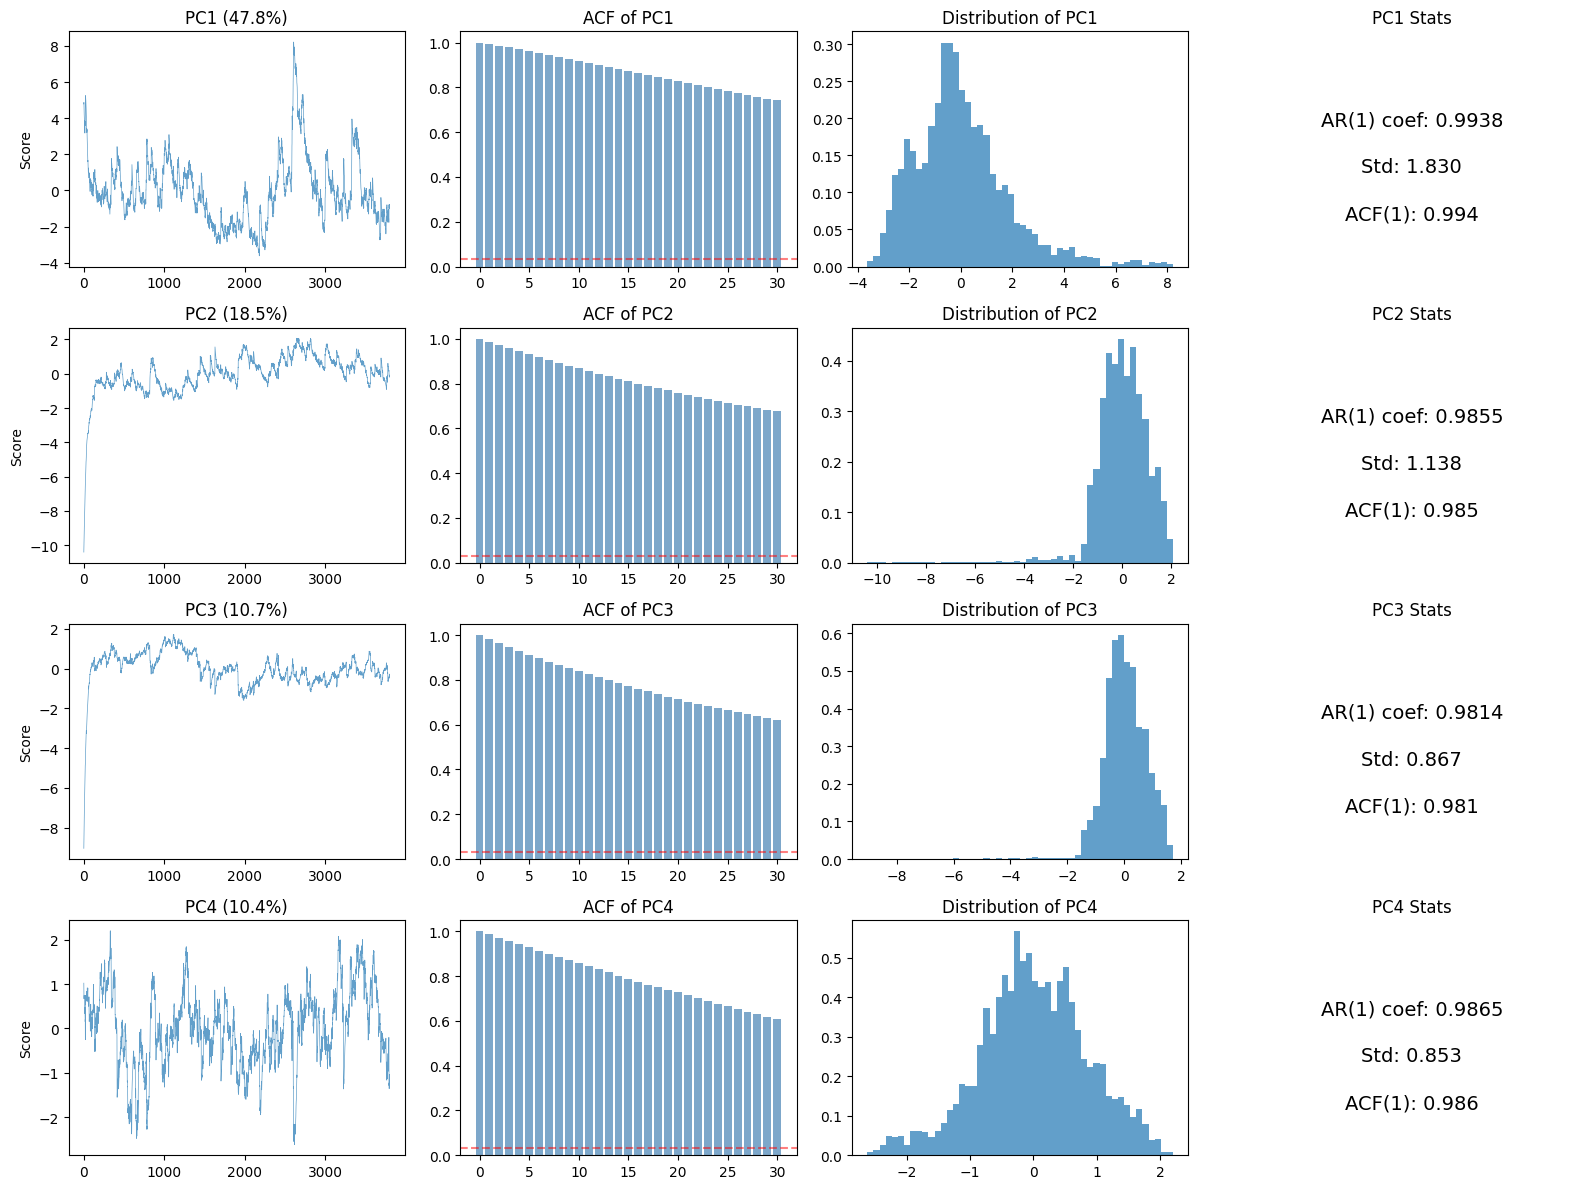


FACTOR LOADINGS (first 4 PCs)
                PC1    PC2    PC3    PC4
gurkor        0.444  0.080  0.121  0.252
guitars       0.471 -0.212  0.228 -0.096
slingshots    0.463  0.173  0.008 -0.279
stocks       -0.131  0.627  0.746 -0.110
sugar         0.433 -0.086 -0.045 -0.542
water         0.389  0.080  0.037  0.736
tranquillity  0.102  0.715 -0.611 -0.040


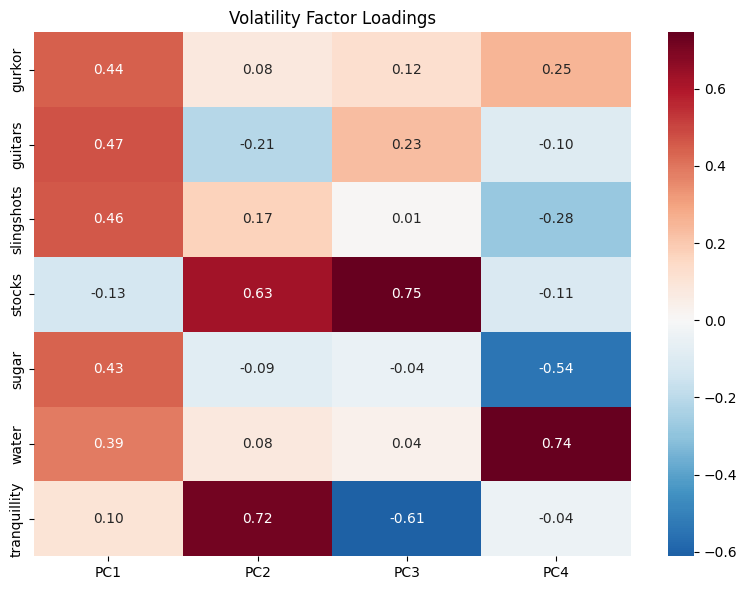


INTERPRETATION

Questions to answer:
1. How many factors give acceptable reconstruction? (MAE < 0.1?)
2. Do all factors have similar dynamics (AR(1) ~0.99)?
   Or do some factors have different behavior?
3. Which assets load on which factors?
   - PC1: General market vol
   - PC2: ???
   - PC3: ???



In [10]:
"""
Multi-factor analysis: How many vol factors do we need?
And what are the dynamics of each?
"""

import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.ar_model import AutoReg
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')
df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
df_og_returns = df_og_returns - df_og_returns.mean()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Fit GARCH, extract conditional variances
cond_var = pd.DataFrame(index=df_og_returns.index)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var[col] = res.conditional_volatility ** 2

log_h = np.log(cond_var)
log_h_std = (log_h - log_h.mean()) / log_h.std()

# PCA
pca = PCA(n_components=7)
scores = pca.fit_transform(log_h_std)
loadings = pca.components_.T  # 7 assets x 7 PCs

original_vol_corr = log_h.corr().values

# =============================================================================
# Test reconstruction with 1, 2, 3, 4 factors
# =============================================================================
print("="*60)
print("RECONSTRUCTION QUALITY BY NUMBER OF FACTORS")
print("="*60)

mask = ~np.eye(7, dtype=bool)
orig_offdiag = original_vol_corr[mask]

for n_factors in [1, 2, 3, 4, 5]:
    # Reconstruct using first n factors
    recon = scores[:, :n_factors] @ pca.components_[:n_factors, :]
    recon_corr = np.corrcoef(recon.T)
    recon_offdiag = recon_corr[mask]
    
    corr_recovery = np.corrcoef(orig_offdiag, recon_offdiag)[0, 1]
    mae = np.mean(np.abs(orig_offdiag - recon_offdiag))
    max_err = np.max(np.abs(orig_offdiag - recon_offdiag))
    var_explained = pca.explained_variance_ratio_[:n_factors].sum()
    
    print(f"\n{n_factors} factor(s): {var_explained:.1%} variance explained")
    print(f"  Correlation recovery: {corr_recovery:.3f}")
    print(f"  MAE: {mae:.3f}, Max error: {max_err:.3f}")

# =============================================================================
# Visualize: Original vs 2-factor vs 3-factor reconstruction
# =============================================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.heatmap(pd.DataFrame(original_vol_corr, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='BrBG', center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Original Vol Correlations')

for idx, n_factors in enumerate([2, 3, 4]):
    recon = scores[:, :n_factors] @ pca.components_[:n_factors, :]
    recon_corr = np.corrcoef(recon.T)
    
    sns.heatmap(pd.DataFrame(recon_corr, index=var_names, columns=var_names),
                annot=True, fmt='.2f', cmap='BrBG', center=0, ax=axes[idx+1], vmin=-1, vmax=1)
    axes[idx+1].set_title(f'{n_factors}-Factor Reconstruction\n({pca.explained_variance_ratio_[:n_factors].sum():.1%} var)')

plt.tight_layout()
plt.show()

# =============================================================================
# Analyze dynamics of each factor
# =============================================================================
print("\n" + "="*60)
print("DYNAMICS OF EACH VOLATILITY FACTOR")
print("="*60)

fig, axes = plt.subplots(4, 4, figsize=(16, 12))

for i in range(4):
    factor = scores[:, i]
    
    # Time series
    axes[i, 0].plot(factor, alpha=0.7, linewidth=0.5)
    axes[i, 0].set_title(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
    axes[i, 0].set_ylabel('Score')
    
    # ACF
    acf_vals = acf(factor, nlags=30, fft=True)
    axes[i, 1].bar(range(len(acf_vals)), acf_vals, color='steelblue', alpha=0.7)
    axes[i, 1].axhline(0, color='black', linewidth=0.5)
    axes[i, 1].axhline(1.96/np.sqrt(len(factor)), color='red', linestyle='--', alpha=0.5)
    axes[i, 1].set_title(f'ACF of PC{i+1}')
    
    # Distribution
    axes[i, 2].hist(factor, bins=50, density=True, alpha=0.7)
    axes[i, 2].set_title(f'Distribution of PC{i+1}')
    
    # Fit AR(1) and show persistence
    ar_model = AutoReg(factor, lags=1, trend='c').fit()
    ar_coef = ar_model.params[1]
    
    axes[i, 3].text(0.5, 0.6, f'AR(1) coef: {ar_coef:.4f}', 
                    transform=axes[i, 3].transAxes, fontsize=14, ha='center')
    axes[i, 3].text(0.5, 0.4, f'Std: {factor.std():.3f}', 
                    transform=axes[i, 3].transAxes, fontsize=14, ha='center')
    axes[i, 3].text(0.5, 0.2, f'ACF(1): {acf_vals[1]:.3f}', 
                    transform=axes[i, 3].transAxes, fontsize=14, ha='center')
    axes[i, 3].axis('off')
    axes[i, 3].set_title(f'PC{i+1} Stats')

plt.tight_layout()
plt.show()

# =============================================================================
# Factor loadings heatmap
# =============================================================================
print("\n" + "="*60)
print("FACTOR LOADINGS (first 4 PCs)")
print("="*60)

loadings_df = pd.DataFrame(
    loadings[:, :4],
    index=var_names,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)
print(loadings_df.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Volatility Factor Loadings')
plt.tight_layout()
plt.show()

# =============================================================================
# Interpretation
# =============================================================================
print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
print("""
Questions to answer:
1. How many factors give acceptable reconstruction? (MAE < 0.1?)
2. Do all factors have similar dynamics (AR(1) ~0.99)?
   Or do some factors have different behavior?
3. Which assets load on which factors?
   - PC1: General market vol
   - PC2: ???
   - PC3: ???
""")

FACTOR DYNAMICS (for simulation)

PC1:
  AR(1) phi:     0.9938
  Intercept c:   -0.0015
  Resid std:     0.1893
  Uncond mean:   -0.2366
  Empirical std: 1.8297

PC2:
  AR(1) phi:     0.9855
  Intercept c:   0.0027
  Resid std:     0.0942
  Uncond mean:   0.1867
  Empirical std: 1.1381

PC3:
  AR(1) phi:     0.9814
  Intercept c:   0.0023
  Resid std:     0.0786
  Uncond mean:   0.1227
  Empirical std: 0.8668

PC4:
  AR(1) phi:     0.9865
  Intercept c:   -0.0006
  Resid std:     0.1400
  Uncond mean:   -0.0435
  Empirical std: 0.8530

PC5:
  AR(1) phi:     0.9833
  Intercept c:   0.0001
  Resid std:     0.1150
  Uncond mean:   0.0030
  Empirical std: 0.6313

FACTOR LOADINGS (4 factors x 7 assets)
                 PC1     PC2     PC3     PC4     PC5
gurkor        0.4441  0.0795  0.1213  0.2519  0.7852
guitars       0.4710 -0.2119  0.2279 -0.0956 -0.3453
slingshots    0.4627  0.1729  0.0081 -0.2791 -0.3598
stocks       -0.1310  0.6272  0.7457 -0.1104 -0.0153
sugar         0.4334 -0.0864

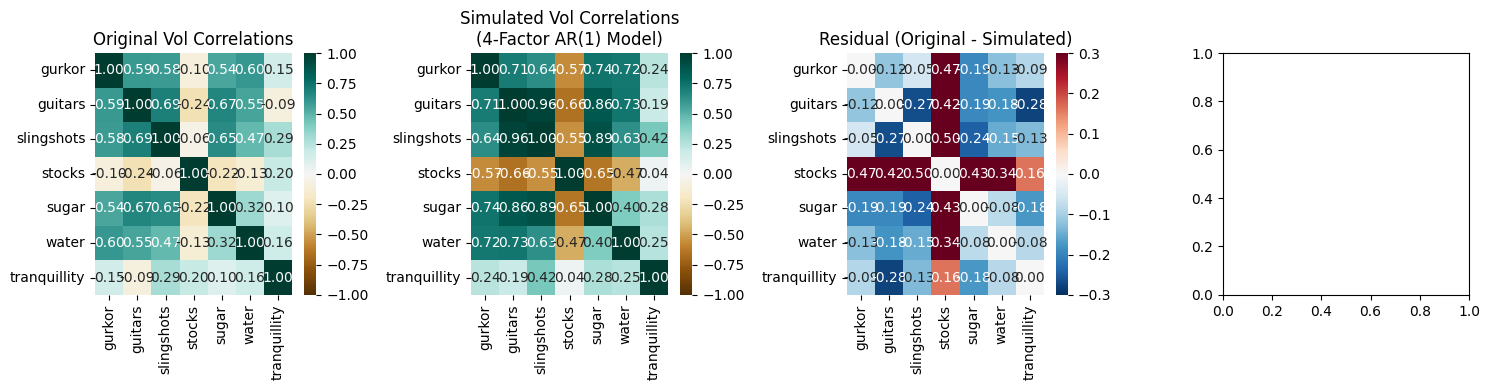


COPY THESE PARAMETERS FOR MAIN SIMULATION

# 4-Factor AR(1) Volatility Model Parameters
vol_factor_params = {
    'PC1': {'phi': 0.993754, 'c': -0.001478, 'resid_std': 0.189316},
    'PC2': {'phi': 0.985462, 'c': 0.002715, 'resid_std': 0.094177},
    'PC3': {'phi': 0.981409, 'c': 0.002281, 'resid_std': 0.078645},
    'PC4': {'phi': 0.986527, 'c': -0.000586, 'resid_std': 0.139952},
    'PC5': {'phi': 0.983293, 'c': 0.000051, 'resid_std': 0.115022},
}

# Loadings matrix (7 assets x 4 factors)
vol_loadings = np.array([
    [  0.4441,   0.0795,   0.1213,   0.2519,   0.7852],  # gurkor
    [  0.4710,  -0.2119,   0.2279,  -0.0956,  -0.3453],  # guitars
    [  0.4627,   0.1729,   0.0081,  -0.2791,  -0.3598],  # slingshots
    [ -0.1310,   0.6272,   0.7457,  -0.1104,  -0.0153],  # stocks
    [  0.4334,  -0.0864,  -0.0445,  -0.5417,   0.2196],  # sugar
    [  0.3893,   0.0801,   0.0370,   0.7364,  -0.2921],  # water
    [  0.1019,   0.7153,  -0.6114,  -0.0399,  -0.0300],  # tranquillity
])

# 

In [8]:
"""
4-Factor Volatility Model Implementation

Simulate 4 independent AR(1) processes for volatility factors,
then reconstruct correlated conditional variances via loadings.
"""

import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# Setup - get the parameters we need
# =============================================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')
df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
df_og_returns = df_og_returns - df_og_returns.mean()

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Fit GARCH, extract conditional variances
cond_var = pd.DataFrame(index=df_og_returns.index)
for col in var_names:
    model = arch_model(df_og_returns[col] * 1000, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')
    cond_var[col] = res.conditional_volatility ** 2

log_h = np.log(cond_var)

# Store means and stds for reconstruction
log_h_means = log_h.mean()
log_h_stds = log_h.std()

log_h_std = (log_h - log_h_means) / log_h_stds

# PCA
pca = PCA(n_components=7)
scores = pca.fit_transform(log_h_std)
loadings = pca.components_[:5, :].T  # 7 assets x 4 PCs

# =============================================================================
# Extract AR(1) parameters for each factor
# =============================================================================
from statsmodels.tsa.ar_model import AutoReg

print("="*60)
print("FACTOR DYNAMICS (for simulation)")
print("="*60)

factor_params = {}
for i in range(5):
    factor = scores[:, i]
    ar_model = AutoReg(factor, lags=1, trend='c').fit()
    
    # AR(1): x_t = c + phi*x_{t-1} + epsilon
    # where epsilon ~ N(0, sigma^2)
    c = ar_model.params[0]
    phi = ar_model.params[1]
    resid_std = np.std(ar_model.resid)
    
    # Unconditional mean = c / (1 - phi)
    uncond_mean = c / (1 - phi)
    
    factor_params[f'PC{i+1}'] = {
        'phi': phi,
        'c': c,
        'resid_std': resid_std,
        'uncond_mean': uncond_mean,
        'empirical_std': factor.std()
    }
    
    print(f"\nPC{i+1}:")
    print(f"  AR(1) phi:     {phi:.4f}")
    print(f"  Intercept c:   {c:.4f}")
    print(f"  Resid std:     {resid_std:.4f}")
    print(f"  Uncond mean:   {uncond_mean:.4f}")
    print(f"  Empirical std: {factor.std():.4f}")

# =============================================================================
# Print loadings for simulation
# =============================================================================
print("\n" + "="*60)
print("FACTOR LOADINGS (4 factors x 7 assets)")
print("="*60)
loadings_df = pd.DataFrame(loadings, index=var_names, columns=['PC1', 'PC2', 'PC3', 'PC4','PC5'])
print(loadings_df.round(4))

# =============================================================================
# Simulation function
# =============================================================================
def simulate_vol_factors(T, factor_params, burn=500):
    """
    Simulate 4 independent AR(1) volatility factors
    """
    n_factors = 5
    T_total = T + burn
    
    factors = np.zeros((T_total, n_factors))
    
    for i in range(n_factors):
        p = factor_params[f'PC{i+1}']
        phi = p['phi']
        c = p['c']
        sigma = p['resid_std']
        
        # Initialize at unconditional mean
        factors[0, i] = p['uncond_mean']
        
        # Simulate AR(1)
        for t in range(1, T_total):
            factors[t, i] = c + phi * factors[t-1, i] + sigma * np.random.randn()
    
    return factors[burn:]

# =============================================================================
# Test: Simulate and compare vol correlations
# =============================================================================
print("\n" + "="*60)
print("SIMULATION TEST")
print("="*60)

np.random.seed(42)
T_sim = 4000

# Simulate factors
factors_sim = simulate_vol_factors(T_sim, factor_params)

# Reconstruct standardized log(h) via loadings
log_h_sim_std = factors_sim @ loadings.T  # (T x 7)

# Compute correlation of simulated log(h)
sim_vol_corr = np.corrcoef(log_h_sim_std.T)
original_vol_corr = log_h.corr().values

print("\nOriginal vol correlations:")
print(pd.DataFrame(original_vol_corr, index=var_names, columns=var_names).round(2))

print("\nSimulated vol correlations (4-factor model):")
print(pd.DataFrame(sim_vol_corr, index=var_names, columns=var_names).round(2))

# Compute error
mask = ~np.eye(7, dtype=bool)
mae = np.mean(np.abs(original_vol_corr[mask] - sim_vol_corr[mask]))
max_err = np.max(np.abs(original_vol_corr[mask] - sim_vol_corr[mask]))
print(f"\nMAE: {mae:.3f}, Max error: {max_err:.3f}")

# =============================================================================
# Visualize comparison
# =============================================================================
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

sns.heatmap(pd.DataFrame(original_vol_corr, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='BrBG', center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Original Vol Correlations')

sns.heatmap(pd.DataFrame(sim_vol_corr, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='BrBG', center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Simulated Vol Correlations\n(4-Factor AR(1) Model)')

residual = original_vol_corr - sim_vol_corr
sns.heatmap(pd.DataFrame(residual, index=var_names, columns=var_names),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[2], vmin=-0.3, vmax=0.3)
axes[2].set_title('Residual (Original - Simulated)')

plt.tight_layout()
plt.show()

# =============================================================================
# Print final parameters for main simulation
# =============================================================================
print("\n" + "="*60)
print("COPY THESE PARAMETERS FOR MAIN SIMULATION")
print("="*60)

print("""
# 4-Factor AR(1) Volatility Model Parameters
vol_factor_params = {""")
for i in range(5):
    p = factor_params[f'PC{i+1}']
    print(f"    'PC{i+1}': {{'phi': {p['phi']:.6f}, 'c': {p['c']:.6f}, 'resid_std': {p['resid_std']:.6f}}},")
print("}")

print("\n# Loadings matrix (7 assets x 4 factors)")
print("vol_loadings = np.array([")
for i, name in enumerate(var_names):
    row = loadings[i, :]
    print(f"    [{row[0]:8.4f}, {row[1]:8.4f}, {row[2]:8.4f}, {row[3]:8.4f}, {row[4]:8.4f}],  # {name}")
print("])")

print("\n# Log-variance normalization (to convert back from standardized)")
print("log_h_means = {")
for name in var_names:
    print(f"    '{name}': {log_h_means[name]:.4f},")
print("}")
print("\nlog_h_stds = {")
for name in var_names:
    print(f"    '{name}': {log_h_stds[name]:.4f},")
print("}")

In [9]:
import numpy as np
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg

def fit_ar_on_blocks(data, states, regime, lags=1):
    """Fits AR(1) only on contiguous sequences of the same regime."""
    diff = np.diff(np.where(states == regime, 1, 0), prepend=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    
    # Collect all valid y_t, y_{t-1} pairs within the same regime block
    y, x = [], []
    for s, e in zip(starts, ends):
        block = data[s:e]
        if len(block) > lags:
            for i in range(lags, len(block)):
                y.append(block[i])
                x.append(block[i-1])
    
    # Simple OLS for the AR(1) coefficient phi on de-meaned data
    y, x = np.array(y), np.array(x)
    mu = np.mean(data[states == regime])
    y_dm, x_dm = y - mu, x - mu
    phi = np.sum(x_dm * y_dm) / np.sum(x_dm**2)
    sigma = np.std(y_dm - phi * x_dm)
    return phi, sigma

# --- APPLYING THE ROBUST FIT ---
ar_params = {}
for r in [0, 1]:
    phi, sigma = fit_ar_on_blocks(common_vol_flat, states_original, r)
    ar_params[r] = {'ar1': phi, 'sigma': sigma, 'mu': regime_means[r]}

# --- SIMULATION (Same logic, ensured mean stability) ---
np.random.seed(42)
common_vol_sim = np.zeros(len(common_vol_flat))
regime_sim = np.zeros(len(common_vol_flat), dtype=int)
regime_sim[0] = states_original[0]
common_vol_sim[0] = common_vol_flat[0]

for t in range(1, len(common_vol_flat)):
    r_prev = regime_sim[t-1]
    r_curr = np.random.choice(2, p=transition_matrix[r_prev])
    regime_sim[t] = r_curr
    
    p = ar_params[r_curr]
    dev_prev = common_vol_sim[t-1] - ar_params[r_prev]['mu']
    
    # Note: We cap phi at 0.99 to prevent explosion if data is near-unit-root
    phi_eff = min(p['ar1'], 0.99)
    common_vol_sim[t] = p['mu'] + phi_eff * dev_prev + np.random.normal(0, p['sigma'])


# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
pd.Series(common_vol_flat).plot(
    ax=axes[0], title='Original Common Vol Factor', alpha=0.8)

pd.Series(common_vol_sim).plot(
    ax=axes[1], title='Simulated (Markov + AR(1))', color='orange', alpha=0.8)

# Overlay regimes
ax2 = axes[1].twinx()
pd.Series(regime_sim.astype(float)).plot(
    ax=ax2, color='red', alpha=0.2, linewidth=0.5)

# ACF comparison
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(common_vol_flat, lags=30, ax=axes[2], alpha=0.05)
plot_acf(common_vol_sim, lags=30, ax=axes[2], alpha=0.05, color='orange')
axes[2].set_title('ACF Comparison (blue=original, orange=simulated)')
plt.tight_layout()
plt.show()

print(f"\nOriginal: mean={common_vol_flat.mean():.3f}, std={common_vol_flat.std():.3f}")
print(f"Simulated: mean={common_vol_sim.mean():.3f}, std={common_vol_sim.std():.3f}")

NameError: name 'common_vol_flat' is not defined

In [ ]:
# Create a DataFrame to count transitions
df_trans = pd.DataFrame({'prev': states_original[:-1], 'curr': states_original[1:]})

# Calculate the transition probabilities (normalized by row)
emp_trans_matrix = pd.crosstab(df_trans['prev'], df_trans['curr'], normalize='index').values

print("Empirical Transition Matrix:\n", emp_trans_matrix)

Empirical Transition Matrix:
 [[0.99451477 0.00548523]
 [0.00980392 0.99019608]]


In [ ]:
# --- SIMULATION WITH EMPIRICAL MATRIX ---
np.random.seed(42)
common_vol_sim = np.zeros(T_sim)
regime_sim = np.zeros(T_sim, dtype=int)

# Use the empirical matrix for transitions
trans_mat = emp_trans_matrix 

# Start in the same state as the original data
regime_sim[0] = states_original[0] 
common_vol_sim[0] = common_vol_flat[0]

for t in range(1, T_sim):
    prev_r = regime_sim[t-1]
    # Transition using the EMPIRICAL matrix
    curr_r = np.random.choice(2, p=trans_mat[prev_r])
    regime_sim[t] = curr_r
    
    p = ar_params[curr_r]
    # Use the residual logic from before
    prev_dev = common_vol_sim[t-1] - ar_params[prev_r]['mu']
    
    common_vol_sim[t] = (ar_params[curr_r]['mu'] + 
                         p['ar1'] * prev_dev + 
                         np.random.normal(0, p['sigma']))

# Final Verification
print("New Simulated State Freq:", pd.Series(regime_sim).value_counts(normalize=True))
print(f"Simulated Mean: {common_vol_sim.mean():.3f}")

New Simulated State Freq: 0    0.683714
1    0.316286
Name: proportion, dtype: float64
Simulated Mean: -0.217


In [ ]:
# --- RECONSTRUCTION TEST ---
# Use the EXACT same states as the original to verify AR(1) parameters
regime_sim = states_original[:T_sim] 
common_vol_sim = np.zeros(T_sim)
common_vol_sim[0] = common_vol_flat[0]

for t in range(1, T_sim):
    r_prev = regime_sim[t-1]
    r_curr = regime_sim[t] # No randomness here, use historical state
    
    p = ar_params[r_curr]
    prev_dev = common_vol_sim[t-1] - ar_params[r_prev]['mu']
    
    common_vol_sim[t] = (ar_params[r_curr]['mu'] + 
                         p['ar1'] * prev_dev + 
                         np.random.normal(0, p['sigma']))

print(f"Reconstruction Mean: {common_vol_sim.mean():.3f}")
print(f"Reconstruction Std: {common_vol_sim.std():.3f}")

Reconstruction Mean: 0.068
Reconstruction Std: 1.325


In [ ]:
# First check exactly what's in ar_params
for regime in [0, 1]:
    print(f"\nRegime {regime}:")
    for k, v in ar_params[regime].items():
        print(f"  {k}: {v:.4f}")

# The unconditional mean of AR(1) is: mu = const / (1 - ar1)
# NOT the regime mean from HMM directly
for regime in [0, 1]:
    p = ar_params[regime]
    mu_implied = p['const'] / (1 - p['ar1'])
    print(f"Regime {regime}: const={p['const']:.4f}, ar1={p['ar1']:.4f}, "
          f"implied_mu={mu_implied:.4f}, hmm_mean={regime_means[regime]:.4f}")


Regime 0:
  ar1: 0.9795
  sigma: 0.1180
  mu: -0.6890

Regime 1:
  ar1: 0.9893
  sigma: 0.1458
  mu: 1.1536


KeyError: 'const'

In [ ]:
# Redefine ar_params cleanly with correct mu
ar_params = {}
for regime in [0, 1]:
    mask = states_original == regime
    regime_data = common_vol_flat[mask]
    
    ar_model = AutoReg(regime_data, lags=1).fit()
    const = ar_model.params[0]
    ar1 = ar_model.params[1]
    mu = const / (1 - ar1)  # true unconditional mean
    sigma = np.sqrt(ar_model.sigma2)
    
    ar_params[regime] = {
        'const': const,
        'ar1': ar1,
        'mu': mu,
        'sigma': sigma
    }
    print(f"Regime {regime}: ar1={ar1:.4f}, mu={mu:.4f}, "
          f"hmm_mean={regime_means[regime]:.4f}, sigma={sigma:.4f}")

# Now simulate cleanly
np.random.seed(69)
common_vol_sim = np.zeros(T_sim)
regime_sim = np.zeros(T_sim, dtype=int)

regime_sim[0] = np.random.choice(2, p=[pi0, pi1])
common_vol_sim[0] = ar_params[regime_sim[0]]['mu']

for t in range(1, T_sim):
    regime_sim[t] = np.random.choice(2, p=transition_matrix[regime_sim[t-1]])
    r_curr = regime_sim[t]
    r_prev = regime_sim[t-1]
    p_curr = ar_params[r_curr]
    p_prev = ar_params[r_prev]
    
    # Mean-revert around current regime's unconditional mean
    prev_dev = common_vol_sim[t-1] - p_prev['mu']
    common_vol_sim[t] = (p_curr['mu'] + 
                         p_curr['ar1'] * prev_dev + 
                         np.random.normal(0, p_curr['sigma']))

print(f"\nSimulated mean: {common_vol_sim.mean():.3f} (target: {common_vol_flat.mean():.3f})")
print(f"Simulated std:  {common_vol_sim.std():.3f} (target: {common_vol_flat.std():.3f})")
print(f"State freq:\n{pd.Series(regime_sim).value_counts(normalize=True).sort_index()}")

Regime 0: ar1=0.9778, mu=-0.4945, hmm_mean=-4.7226, sigma=0.1488
Regime 1: ar1=0.9773, mu=1.4585, hmm_mean=-4.2497, sigma=0.2290

Simulated mean: 0.027 (target: -0.000)
Simulated std:  1.159 (target: 1.169)
State freq:
0    0.721143
1    0.278857
Name: proportion, dtype: float64


In [ ]:
Nästa steg: skew!

SyntaxError: invalid syntax (507249967.py, line 1)